# One global model, regional models, or models per group of regions?

**Is a single model trained on the whole of Cameroon better than a model
dedicated to each health region?**

---

## The question and why it matters

The current system uses **one national model**. That is a default choice, never
tested. Yet both options have theoretical reasons to win:

| Approach | Argument in its favour | Risk |
|---|---|---|
| **Global** | 7 092 observations, learns the shared regularities | dilutes local specificities |
| **Regional** | captures the epidemiology proper to each region | only 360 to 1 152 rows per model |
| **Per group** | compromise: pools similar regions | depends on the quality of the grouping |

This is the classic **bias/variance** trade-off applied to geography. The results
of this project make it particularly relevant: feature importance is dominated by
geography (`SHP_lat`, `SHP_lon`, `SHP_Area`, `cluster`), which suggests the
global model already spends part of its capacity telling regions apart — work a
regional model would not have to do.

## Protocol

* **Strictly identical evaluation** for the three approaches: same test rows,
  same metrics. Without that the comparison means nothing.
* **Rolling-origin validation**: several successive temporal splits, never a
  single one, so the conclusion does not rest on a calendar accident.
* **No leakage**: the test set is always later than the training set, and the
  clustering of regions is learnt **on the training data only**.
* Regression target: `log_incidence`. Classification target: `high`
  (incidence > 75th percentile **of its own region**).

---
## 0 · Setup

In [1]:
import warnings, json, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from rapidfuzz import process, fuzz
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             f1_score, roc_auc_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
np.random.seed(SEED)
BLUE, ORANGE, GREEN, RED = '#378ADD', '#D85A30', '#639922', '#E24B4A'
GREY, PURPLE = '#7f8c8d', '#8e44ad'

HERE = Path.cwd()
ROOT = HERE.parent if (HERE.parent / '1_DATA').is_dir() else HERE
DATA = ROOT / '1_DATA'
OUT_DIR = HERE / 'figures'; OUT_DIR.mkdir(exist_ok=True)

FEAT = ['sin_month', 'cos_month', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
        'Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm',
        'Temperature_C_lag1', 'Temperature_C_lag2',
        'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
        'Humidity_pct_lag1', 'Humidity_pct_lag2']

print('Environment ready ·', 'python', sys.version.split()[0], '· xgboost', xgb.__version__)
print('Data:', DATA)

Environment ready · python 3.12.10 · xgboost 3.3.0
Data: d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\1_DATA


In [2]:
# ── Merge pipeline, identical to the rest of the project ─────────────────────
MONTH_MAP = {'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
FUZZY_MAP = {'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South',
             'Maroua 2':'Maroua 1','Maroua 3':'Maroua 1',
             'Ngaoundere Urbain':'Ngaoundere Rural','Maga':'Mada',
             'Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}


def build_panel():
    """District x month: PNLP cases merged with the monthly climate."""
    raw = pd.read_csv(DATA / 'PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv', sep=';')
    for c in ('SHP_lat', 'SHP_lon', 'SHP_Area'):
        raw[c] = pd.to_numeric(raw[c].astype(str).str.replace(',', '.'), errors='coerce')

    mape = [c for c in raw.columns if 'MAPE16_H_13' in c]
    static = (raw.groupby(['district', 'region'])
              .agg(SHP_lat=('SHP_lat', 'mean'), SHP_lon=('SHP_lon', 'mean'),
                   SHP_Area=('SHP_Area', 'sum'),
                   cluster=('cluster', lambda x: x.mode()[0]),
                   p_totale=('p_totale', 'sum')).reset_index())
    wide = raw.groupby(['district', 'region'])[mape].sum().reset_index()

    d = wide.melt(id_vars=['district', 'region'], value_vars=mape,
                  var_name='col', value_name='cases')
    d['date'] = d['col'].map(
        lambda c: pd.Timestamp(f"{c.split('_')[1]}-{MONTH_MAP[c.split('_')[0]]}-01")
        if c.split('_')[0] in MONTH_MAP else None)
    d = d.dropna(subset=['date']).drop(columns='col').merge(static, on=['district', 'region'])
    d['incidence_rate'] = d['cases'] / d['p_totale'] * 1000

    clim = pd.read_csv(DATA / 'cameroon_districts_climate.csv', parse_dates=['Date'])
    monthly = (clim.groupby(['Location', pd.Grouper(key='Date', freq='MS')])
               .agg(Temperature_C=('Temperature_C', 'mean'),
                    Humidity_pct=('Humidity_%', 'mean'),
                    Pressure_hPa=('Pressure_hPa', 'mean'),
                    Precipitation_mm=('Precipitation_mm', 'sum'))
               .reset_index().rename(columns={'Date': 'date', 'Location': 'location'}))

    locs = clim['Location'].unique().tolist(); known = set(locs)

    def match(name):
        if name in known:      return name
        if name in FUZZY_MAP:  return FUZZY_MAP[name]
        b = process.extractOne(name, locs, scorer=fuzz.token_sort_ratio)
        return b[0] if b and b[1] >= 55 else None

    d['cloc'] = d['district'].map(match)
    d = (d.merge(monthly, left_on=['cloc', 'date'], right_on=['location', 'date'],
                 how='left').drop(columns='location'))
    for c in ('Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm'):
        d[c] = d[c].fillna(d.groupby(['region', 'date'])[c].transform('mean')).fillna(d[c].mean())

    d['month'] = d['date'].dt.month
    d['sin_month'] = np.sin(2 * np.pi * d['month'] / 12)
    d['cos_month'] = np.cos(2 * np.pi * d['month'] / 12)
    d = d.sort_values(['district', 'date'])
    for c in ('Temperature_C', 'Precipitation_mm', 'Humidity_pct'):
        d[f'{c}_lag1'] = d.groupby('district')[c].shift(1)
        d[f'{c}_lag2'] = d.groupby('district')[c].shift(2)

    d['log_incidence'] = np.log1p(d['incidence_rate'])
    thr = d.groupby('region')['incidence_rate'].quantile(0.75).rename('threshold_75')
    d = d.merge(thr, on='region')
    d['high'] = (d['incidence_rate'] > d['threshold_75']).astype(int)

    return (d.dropna(subset=['Temperature_C_lag1', 'Temperature_C_lag2'])
            .sort_values('date').reset_index(drop=True))


t0 = time.time()
panel = build_panel()
print(f'Panel: {panel.shape} in {time.time()-t0:.1f}s')
print(f'  {panel.district.nunique()} districts · {panel.region.nunique()} regions · '
      f'{panel.date.nunique()} months ({panel.date.min():%Y-%m} -> {panel.date.max():%Y-%m})')

Panel: (7092, 27) in 2.6s
  197 districts · 10 regions · 36 months (2019-03 -> 2022-02)


## 1 · How much data each region has — the heart of the trade-off

A regional model has 5 to 16 times less data than the global model. That
imbalance is what decides whether specialisation is worth the loss of volume.

In [3]:
vol = (panel.groupby('region')
       .agg(rows=('district', 'size'), districts=('district', 'nunique'),
            incidence_mean=('incidence_rate', 'mean'),
            incidence_sd=('incidence_rate', 'std'),
            share_high=('high', 'mean')).reset_index())
vol['share_of_global_%'] = vol['rows'] / len(panel) * 100
vol = vol.sort_values('rows', ascending=False)

print(f'Global model: {len(panel)} rows\n')
display(vol.style.format({'incidence_mean': '{:.2f}', 'incidence_sd': '{:.2f}',
                          'share_high': '{:.1%}', 'share_of_global_%': '{:.1f}'}))

print(f"\nThe smallest regional model ({vol.rows.min()} rows, "
      f"{vol.iloc[-1]['region']}) has "
      f"{len(panel)/vol.rows.min():.0f}x less data than the global one.")
print(f"Mean incidence ranges from {vol.incidence_mean.min():.1f} to "
      f"{vol.incidence_mean.max():.1f} /1000 depending on the region — "
      f"a factor of {vol.incidence_mean.max()/vol.incidence_mean.min():.1f}.")

Global model: 7092 rows



,region,rows,districts,incidence_mean,incidence_sd,share_high,share_of_global_%
1,Centre,1152,32,11.47,7.35,24.9%,16.2
3,Extreme Nord,1152,32,9.17,8.33,26.2%,16.2
4,Littoral,864,24,8.13,4.85,24.7%,12.2
6,Nord Ouest,720,20,6.13,4.42,26.4%,10.2
7,Ouest,720,20,7.80,3.83,25.4%,10.2
9,Sud Ouest,684,19,5.82,4.73,25.1%,9.6
2,Est,540,15,11.04,4.66,25.9%,7.6
5,Nord,540,15,9.27,4.58,25.9%,7.6
0,Adamaoua,360,10,10.75,4.01,26.1%,5.1
8,Sud,360,10,7.52,2.56,25.0%,5.1



The smallest regional model (360 rows, Sud) has 20x less data than the global one.
Mean incidence ranges from 5.8 to 11.5 /1000 depending on the region — a factor of 2.0.


## 2 · Grouping similar regions

A third approach: pool regions that resemble each other, to keep volume without
mixing epidemiologies that are too different.

The grouping is learnt by k-means on the **regional profile** — incidence level,
seasonal amplitude, mean climate, latitude. A point of method: it is fitted **on
each fold's training data only**, otherwise group membership would already encode
information from the test set.

In [4]:
def region_profile(df):
    """Summary of a region: level, seasonality, climate."""
    prof = (df.groupby('region')
            .agg(inc_mean=('incidence_rate', 'mean'),
                 inc_sd=('incidence_rate', 'std'),
                 temp=('Temperature_C', 'mean'),
                 humid=('Humidity_pct', 'mean'),
                 precip=('Precipitation_mm', 'mean'),
                 lat=('SHP_lon', 'mean')))          # SHP_lon = the real latitude
    # Seasonal amplitude: gap between the strongest and the weakest month
    seas = (df.groupby(['region', 'month'])['incidence_rate'].mean()
            .groupby('region').agg(lambda s: s.max() - s.min()).rename('amplitude'))
    return prof.join(seas)


def fit_region_clusters(train_df, k=3):
    """Learn k groups of regions on the training set alone. Returns region -> group."""
    prof = region_profile(train_df)
    Z = StandardScaler().fit_transform(prof.values)
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
    return dict(zip(prof.index, km.labels_)), prof


groups, profile = fit_region_clusters(panel, k=3)
profile['group'] = pd.Series(groups)

print('Regional profile and grouping (fitted here on the whole panel, for illustration):\n')
display(profile.sort_values('group').style.format('{:.2f}', subset=profile.columns[:-1]))

print('\nResulting groups:')
for g in sorted(set(groups.values())):
    members = [r for r, gg in groups.items() if gg == g]
    n = panel[panel.region.isin(members)].shape[0]
    inc = panel[panel.region.isin(members)].incidence_rate.mean()
    print(f'  group {g} · {n:>5} rows · mean incidence {inc:5.2f} · {members}')

Regional profile and grouping (fitted here on the whole panel, for illustration):



,inc_mean,inc_sd,temp,humid,precip,lat,amplitude,group
region,,,,,,,,
Extreme Nord,9.17,8.33,26.81,54.15,79.04,10.86,15.55,0
Nord,9.27,4.58,27.55,53.99,75.12,9.20,11.00,0
Littoral,8.13,4.85,23.91,84.16,196.52,4.29,3.92,1
Nord Ouest,6.13,4.42,20.52,75.58,197.72,6.19,4.89,1
Ouest,7.80,3.83,21.83,77.62,163.35,5.46,4.51,1
Sud,7.52,2.56,24.60,81.15,184.03,2.84,3.17,1
Sud Ouest,5.82,4.73,24.26,80.93,264.62,4.93,1.57,1
Adamaoua,10.75,4.01,23.04,66.67,134.09,6.86,6.57,2
Centre,11.47,7.35,23.95,80.63,151.77,4.09,5.33,2



Resulting groups:
  group 0 ·  1692 rows · mean incidence  9.20 · ['Extreme Nord', 'Nord']
  group 1 ·  3348 rows · mean incidence  7.09 · ['Littoral', 'Nord Ouest', 'Ouest', 'Sud', 'Sud Ouest']
  group 2 ·  2052 rows · mean incidence 11.23 · ['Adamaoua', 'Centre', 'Est']


## 3 · The test bench

A single function trains and evaluates the three approaches on **exactly the same
test rows**, for several temporal origins.

Each origin: train on everything before the cut date, predict the following
`horizon` months.

In [5]:
def make_regressor():
    return xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, verbosity=0)


def make_classifier(scale_pos_weight):
    return xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=scale_pos_weight,
                             random_state=SEED, eval_metric='logloss', verbosity=0)


def _fit_predict(train, test, X_cols=FEAT):
    """Train regressor + classifier on `train`, predict on `test`.

    Returns (pred_log_incidence, pred_high). `None` if the training set is too
    small or holds a single class — a real case for the small regions.
    """
    if len(train) < 50 or test.empty:
        return None, None

    reg = make_regressor()
    reg.fit(train[X_cols], train['log_incidence'])
    pred_reg = reg.predict(test[X_cols])

    n1 = int((train['high'] == 1).sum())
    n0 = int((train['high'] == 0).sum())
    if n1 == 0 or n0 == 0:
        return pred_reg, None
    clf = make_classifier(n0 / max(n1, 1))
    clf.fit(train[X_cols], train['high'])
    return pred_reg, clf.predict(test[X_cols])


def run_fold(panel, cut_date, horizon_months, k_clusters=3):
    """Evaluate the 3 approaches on one temporal split."""
    dates = sorted(panel.date.unique())
    end = pd.Timestamp(cut_date) + pd.DateOffset(months=horizon_months)

    train = panel[panel.date < pd.Timestamp(cut_date)]
    test = panel[(panel.date >= pd.Timestamp(cut_date)) & (panel.date < end)].copy()
    if train.empty or test.empty:
        return None

    # ── A · global ──────────────────────────────────────────────────────────
    pr, pc = _fit_predict(train, test)
    test['pred_global'], test['clf_global'] = pr, pc

    # ── B · regional ────────────────────────────────────────────────────────
    test['pred_regional'] = np.nan
    test['clf_regional'] = np.nan
    for region in sorted(test.region.unique()):
        tr_r = train[train.region == region]
        te_mask = test.region == region
        pr, pc = _fit_predict(tr_r, test[te_mask])
        if pr is not None:
            test.loc[te_mask, 'pred_regional'] = pr
        if pc is not None:
            test.loc[te_mask, 'clf_regional'] = pc

    # ── C · groups of regions (clusters learnt on the TRAIN set alone) ───────
    groups, _ = fit_region_clusters(train, k=k_clusters)
    test['group'] = test.region.map(groups)
    test['pred_cluster'] = np.nan
    test['clf_cluster'] = np.nan
    for g in sorted(set(groups.values())):
        members = [r for r, gg in groups.items() if gg == g]
        tr_g = train[train.region.isin(members)]
        te_mask = test.region.isin(members)
        if te_mask.sum() == 0:
            continue
        pr, pc = _fit_predict(tr_g, test[te_mask])
        if pr is not None:
            test.loc[te_mask, 'pred_cluster'] = pr
        if pc is not None:
            test.loc[te_mask, 'clf_cluster'] = pc

    test['cut'] = pd.Timestamp(cut_date)
    return test


print('Test bench ready: run_fold(panel, cut_date, horizon_months)')

Test bench ready: run_fold(panel, cut_date, horizon_months)


In [6]:
# ── Rolling origins ──────────────────────────────────────────────────────────
# 36 months available. Train on at least 18 months, then test on the following
# 6 months, shifting the origin by 6 months each time.
HORIZON = 6
dates = sorted(panel.date.unique())
cuts = [pd.Timestamp(dates[i]) for i in range(18, len(dates) - HORIZON + 1, HORIZON)]

print(f'{len(cuts)} origins: ' + ', '.join(f'{c:%Y-%m}' for c in cuts))
print(f'test horizon: {HORIZON} months\n')

t0 = time.time()
folds = []
for c in cuts:
    r = run_fold(panel, c, HORIZON)
    if r is not None:
        folds.append(r)
        print(f'  origin {c:%Y-%m} · train < {c:%Y-%m} · test {len(r)} rows '
              f'({time.time()-t0:5.1f}s)')

evald = pd.concat(folds, ignore_index=True)
print(f'\n{len(evald)} test rows in total, over {len(folds)} folds '
      f'({time.time()-t0:.1f}s)')

3 origins: 2020-09, 2021-03, 2021-09
test horizon: 6 months



  origin 2020-09 · train < 2020-09 · test 1182 rows ( 32.4s)


  origin 2021-03 · train < 2021-03 · test 1182 rows ( 65.4s)


  origin 2021-09 · train < 2021-09 · test 1182 rows (100.0s)

3546 test rows in total, over 3 folds (100.1s)


## 4 · Results

In [7]:
APPROACHES = {'global': 'Global model', 'regional': 'Regional models',
              'cluster': 'Group models'}


def metrics(df, approach):
    """Metrics of one approach on a given subset."""
    pcol, ccol = f'pred_{approach}', f'clf_{approach}'
    ok = df[pcol].notna()
    if ok.sum() < 5:
        return None

    y = df.loc[ok, 'log_incidence']
    p = df.loc[ok, pcol]
    y_nat, p_nat = np.expm1(y), np.expm1(p)

    out = {
        'Approach': APPROACHES[approach], 'n': int(ok.sum()),
        'R2': r2_score(y, p),
        'MAE': mean_absolute_error(y_nat, p_nat),
        'RMSE': float(np.sqrt(mean_squared_error(y_nat, p_nat))),
    }
    mask = y_nat > 1e-6
    out['MAPE_%'] = float(np.mean(np.abs((y_nat[mask] - p_nat[mask]) / y_nat[mask])) * 100)

    cok = df[ccol].notna() & ok
    if cok.sum() >= 5 and df.loc[cok, 'high'].nunique() > 1:
        out['F1'] = f1_score(df.loc[cok, 'high'], df.loc[cok, ccol], zero_division=0)
    else:
        out['F1'] = np.nan
    return out


# Rows where ALL THREE approaches produced a prediction: the only honest basis
# for comparison.
comparable = evald[evald[['pred_global', 'pred_regional', 'pred_cluster']]
                   .notna().all(axis=1)].copy()

print(f'Comparable rows (all 3 approaches predicted): {len(comparable)} '
      f'/ {len(evald)}\n')

overall = pd.DataFrame([metrics(comparable, a) for a in APPROACHES])
print('OVERALL COMPARISON — all regions, all folds')
display(overall.style.format({'R2': '{:+.4f}', 'MAE': '{:.3f}', 'RMSE': '{:.3f}',
                              'MAPE_%': '{:.1f}', 'F1': '{:.3f}'}))

best = overall.loc[overall.R2.idxmax(), 'Approach']
print(f'\n  Best R2: {best}')
print(f'  Largest R2 gap between approaches: '
      f'{overall.R2.max() - overall.R2.min():+.4f}')

Comparable rows (all 3 approaches predicted): 3546 / 3546



OVERALL COMPARISON — all regions, all folds


,Approach,n,R2,MAE,RMSE,MAPE_%,F1
0,Global model,3546,+0.6852,2.356,3.660,27.9,0.702
1,Regional models,3546,+0.6762,2.284,3.501,27.1,0.689
2,Group models,3546,+0.6885,2.284,3.497,27.1,0.703



  Best R2: Group models
  Largest R2 gap between approaches: +0.0123


In [8]:
# ── Breakdown by region ──────────────────────────────────────────────────────
rows = []
for region, g in comparable.groupby('region'):
    for a in APPROACHES:
        m = metrics(g, a)
        if m:
            m['Region'] = region
            rows.append(m)

per_region = pd.DataFrame(rows)
piv_r2 = per_region.pivot(index='Region', columns='Approach', values='R2')
piv_f1 = per_region.pivot(index='Region', columns='Approach', values='F1')
piv_mae = per_region.pivot(index='Region', columns='Approach', values='MAE')

piv_r2['regional gain'] = piv_r2['Regional models'] - piv_r2['Global model']
piv_r2['group gain'] = piv_r2['Group models'] - piv_r2['Global model']
piv_r2 = piv_r2.merge(vol.set_index('region')[['rows']], left_index=True,
                      right_index=True).rename(columns={'rows': 'train volume'})

print('R2 BY REGION')
display(piv_r2.sort_values('regional gain', ascending=False).style.format('{:+.3f}',
        subset=[c for c in piv_r2.columns if c != 'train volume']).format(
        {'train volume': '{:.0f}'}))

n_win_reg = int((piv_r2['regional gain'] > 0).sum())
n_win_clu = int((piv_r2['group gain'] > 0).sum())
print(f"\n  regional beats global in {n_win_reg}/{len(piv_r2)} regions")
print(f"  groups beat global in {n_win_clu}/{len(piv_r2)} regions")

corr = piv_r2[['regional gain', 'train volume']].corr().iloc[0, 1]
print(f"\n  correlation (training volume, regional gain): {corr:+.3f}")
print('  => ' + ('the more data a region has, the more specialisation pays'
                 if corr > 0.3 else
                 'available volume does NOT explain where specialisation pays'))

R2 BY REGION


,Global model,Group models,Regional models,regional gain,group gain,train volume
Sud,0.164544,0.218901,0.246763,0.082219,0.054356,360
Ouest,0.643353,0.710990,0.706835,0.063481,0.067636,720
Nord,0.752326,0.760855,0.802272,0.049946,0.008529,540
Centre,0.703965,0.730339,0.734470,0.030505,0.026375,1152
Extreme Nord,0.728662,0.743362,0.742706,0.014044,0.014700,1152
Adamaoua,0.509897,0.493271,0.499617,-0.010280,-0.016627,360
Littoral,0.662876,0.672707,0.649977,-0.012899,0.009831,864
Sud Ouest,0.660565,0.646489,0.602073,-0.058492,-0.014076,684
Nord Ouest,0.468506,0.418376,0.374494,-0.094012,-0.050129,720
Est,-0.578253,-0.733366,-0.867874,-0.289621,-0.155113,540



  regional beats global in 5/10 regions
  groups beat global in 6/10 regions

  correlation (training volume, regional gain): +0.124
  => available volume does NOT explain where specialisation pays


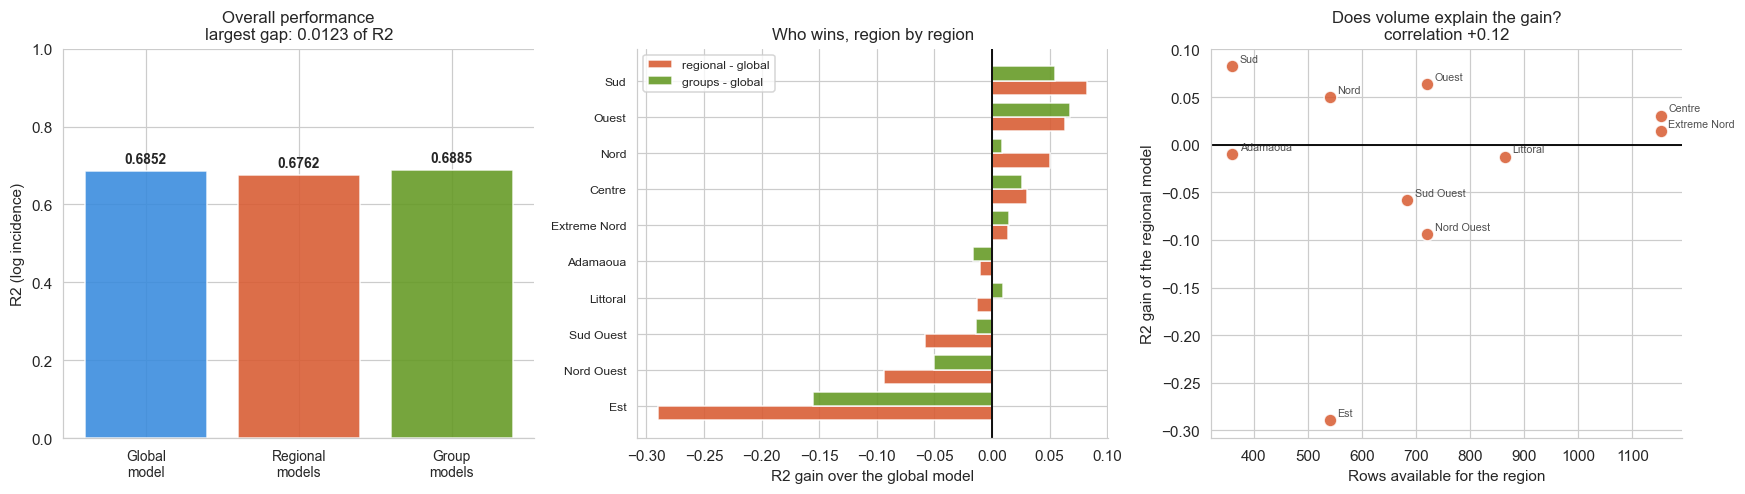

In [9]:
# ══ FIGURE 1 · comparison of the approaches ══════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
palette = {'Global model': BLUE, 'Regional models': ORANGE,
           'Group models': GREEN}

# Overall R2 per approach.
# The axis deliberately starts at 0: with a real gap of ~0.01, a truncated axis
# would make a difference look decisive when it is not.
a = axes[0]
cols = [palette[x] for x in overall.Approach]
bars = a.bar(range(len(overall)), overall.R2, color=cols, alpha=0.88, edgecolor='white')
a.set_xticks(range(len(overall)))
a.set_xticklabels([x.replace(' ', '\n') for x in overall.Approach], fontsize=9)
a.set_ylabel('R2 (log incidence)')
a.set_ylim(0, 1)
gap = overall.R2.max() - overall.R2.min()
a.set_title(f'Overall performance\nlargest gap: {gap:.4f} of R2', fontsize=11)
for b, v in zip(bars, overall.R2):
    a.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.4f}',
           ha='center', fontweight='bold', fontsize=9)

# Gain per region
a = axes[1]
s = piv_r2.sort_values('regional gain')
y = np.arange(len(s))
a.barh(y - 0.2, s['regional gain'], 0.4, color=ORANGE, alpha=0.88,
       edgecolor='white', label='regional - global')
a.barh(y + 0.2, s['group gain'], 0.4, color=GREEN, alpha=0.88,
       edgecolor='white', label='groups - global')
a.axvline(0, color='black', lw=1.2)
a.set_yticks(y); a.set_yticklabels(s.index, fontsize=8)
a.set_xlabel('R2 gain over the global model')
a.set_title('Who wins, region by region', fontsize=11)
a.legend(fontsize=8)

# Gain vs volume
a = axes[2]
a.scatter(s['train volume'], s['regional gain'], s=70, color=ORANGE,
          alpha=0.85, edgecolors='white', zorder=3)
for region, row in s.iterrows():
    a.annotate(region, (row['train volume'], row['regional gain']),
               fontsize=7, alpha=0.8, xytext=(5, 3), textcoords='offset points')
a.axhline(0, color='black', lw=1.2)
a.set_xlabel('Rows available for the region')
a.set_ylabel('R2 gain of the regional model')
a.set_title(f'Does volume explain the gain?\ncorrelation {corr:+.2f}', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_approach_comparison.png', bbox_inches='tight')
plt.show()

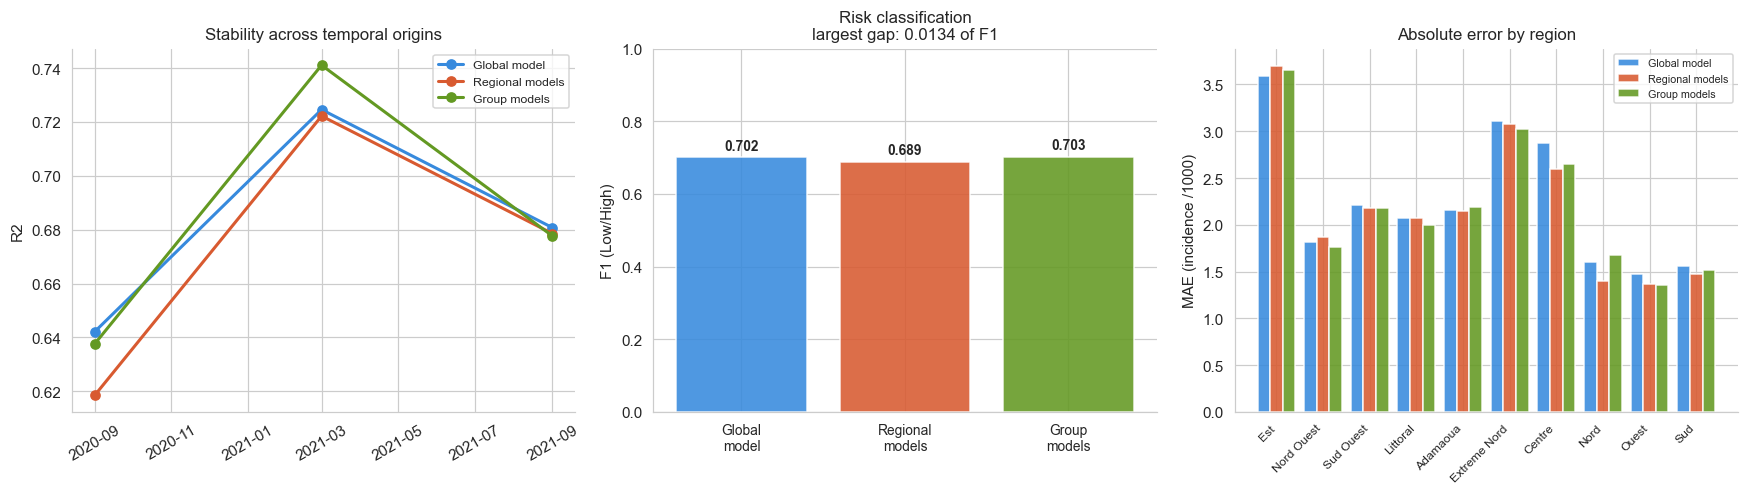

In [10]:
# ══ FIGURE 2 · stability over time and classification ════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# R2 per fold
a = axes[0]
fold_rows = []
for cut, g in comparable.groupby('cut'):
    for ap in APPROACHES:
        m = metrics(g, ap)
        if m:
            m['cut'] = cut
            fold_rows.append(m)
fold_df = pd.DataFrame(fold_rows)
for ap_label, c in palette.items():
    s = fold_df[fold_df.Approach == ap_label]
    a.plot(s.cut, s.R2, '-o', color=c, lw=2, ms=6, label=ap_label)
a.set_ylabel('R2'); a.set_title('Stability across temporal origins', fontsize=11)
a.legend(fontsize=8); a.tick_params(axis='x', rotation=30)

# F1 per approach
a = axes[1]
f1_vals = overall.set_index('Approach')['F1']
bars = a.bar(range(len(f1_vals)), f1_vals.values,
             color=[palette[i] for i in f1_vals.index], alpha=0.88, edgecolor='white')
a.set_xticks(range(len(f1_vals)))
a.set_xticklabels([x.replace(' ', '\n') for x in f1_vals.index], fontsize=9)
a.set_ylabel('F1 (Low/High)')
a.set_ylim(0, 1)                    # full scale, cf. the R2 panel
gap_f1 = f1_vals.max() - f1_vals.min()
a.set_title(f'Risk classification\nlargest gap: {gap_f1:.4f} of F1', fontsize=11)
for b, v in zip(bars, f1_vals.values):
    if np.isfinite(v):
        a.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
               ha='center', fontweight='bold', fontsize=9)

# MAE per region, the 3 approaches
a = axes[2]
s = piv_mae.loc[piv_r2.sort_values('regional gain').index]
x = np.arange(len(s)); w = 0.27
for i, (lab, c) in enumerate(palette.items()):
    a.bar(x + (i - 1) * w, s[lab], w, color=c, alpha=0.88,
          edgecolor='white', label=lab)
a.set_xticks(x); a.set_xticklabels(s.index, rotation=45, ha='right', fontsize=8)
a.set_ylabel('MAE (incidence /1000)')
a.set_title('Absolute error by region', fontsize=11)
a.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_stability_classification.png', bbox_inches='tight')
plt.show()

## 5 · Why some regions show a low R2

A region where all three approaches obtain a mediocre R2 is not necessarily
badly predicted. R2 being a **share of variance explained**, it collapses
mechanically wherever the target varies little — even when the absolute error
stays good. Before concluding failure, R2, variance and MAE must be read
together.

In [11]:
# ── Difficult regions ────────────────────────────────────────────────────────
hard = piv_r2[piv_r2[['Global model', 'Regional models',
                      'Group models']].max(axis=1) < 0.3]
print(f'Regions where NO approach exceeds R2 = 0.30: {list(hard.index)}\n')

def difficulty_profile(g):
    return {
        'incidence_mean': g.incidence_rate.mean(),
        'CV': g.incidence_rate.std() / g.incidence_rate.mean(),
        'volatility_mom': (g.sort_values('date').groupby('district')['incidence_rate']
                           .apply(lambda s: s.diff().abs().mean() / s.mean()).mean()),
        'log_variance': g.log_incidence.var(),
        'districts': g.district.nunique(), 'rows': len(g),
    }

diag = pd.DataFrame({r: difficulty_profile(panel[panel.region == r])
                     for r in panel.region.unique()}).T
diag['R2_max'] = piv_r2[['Global model', 'Regional models',
                         'Group models']].max(axis=1)
diag = diag.sort_values('R2_max')

display(diag.style.format({'incidence_mean': '{:.2f}', 'CV': '{:.2f}',
                           'volatility_mom': '{:.1%}', 'log_variance': '{:.3f}',
                           'R2_max': '{:+.3f}', 'districts': '{:.0f}',
                           'rows': '{:.0f}'}))

r_var = diag[['log_variance', 'R2_max']].corr().iloc[0, 1]
r_vol = diag[['volatility_mom', 'R2_max']].corr().iloc[0, 1]
print(f'\n  correlation (target variance, attainable R2): {r_var:+.3f}')
print(f'  correlation (month-to-month volatility, attainable R2): {r_vol:+.3f}')

print(f"""
  How to read this. R2 measures the share of variance explained: it is
  mechanically low wherever there is little variance to explain. If the
  correlation above between target variance and attainable R2 is strongly
  positive, the "difficult" regions are not difficult because the model fails
  there, but because their incidence is too stable for a high R2 to be possible.

  This is checkable on the MAE: a low-variance region can show a mediocre R2 and
  a perfectly acceptable absolute error. Comparing the two columns below avoids
  condemning a region wrongly.""")

display(pd.concat([diag[['log_variance', 'R2_max']],
                   piv_mae.min(axis=1).rename('MAE_min')],
                  axis=1).sort_values('log_variance')
        .style.format({'log_variance': '{:.3f}', 'R2_max': '{:+.3f}',
                       'MAE_min': '{:.3f}'}))

Regions where NO approach exceeds R2 = 0.30: ['Est', 'Sud']



,incidence_mean,CV,volatility_mom,log_variance,districts,rows,R2_max
Est,11.04,0.42,23.2%,0.180,15,540,-0.578
Sud,7.52,0.34,20.7%,0.082,10,360,+0.247
Nord Ouest,6.13,0.72,30.1%,0.266,20,720,+0.469
Adamaoua,10.75,0.37,20.9%,0.107,10,360,+0.510
Sud Ouest,5.82,0.81,23.3%,0.499,19,684,+0.661
Littoral,8.13,0.60,21.9%,0.266,24,864,+0.673
Ouest,7.80,0.49,20.4%,0.151,20,720,+0.711
Centre,11.47,0.64,19.8%,0.245,32,1152,+0.734
Extreme Nord,9.17,0.91,38.1%,0.560,32,1152,+0.743
Nord,9.27,0.49,25.9%,0.186,15,540,+0.802



  correlation (target variance, attainable R2): +0.328
  correlation (month-to-month volatility, attainable R2): +0.153

  How to read this. R2 measures the share of variance explained: it is
  mechanically low wherever there is little variance to explain. If the
  correlation above between target variance and attainable R2 is strongly
  positive, the "difficult" regions are not difficult because the model fails
  there, but because their incidence is too stable for a high R2 to be possible.

  This is checkable on the MAE: a low-variance region can show a mediocre R2 and
  a perfectly acceptable absolute error. Comparing the two columns below avoids
  condemning a region wrongly.


,log_variance,R2_max,MAE_min
Sud,0.082,+0.247,1.469
Adamaoua,0.107,+0.510,2.146
Ouest,0.151,+0.711,1.352
Est,0.180,-0.578,3.595
Nord,0.186,+0.802,1.396
Centre,0.245,+0.734,2.599
Littoral,0.266,+0.673,1.998
Nord Ouest,0.266,+0.469,1.760
Sud Ouest,0.499,+0.661,2.178
Extreme Nord,0.560,+0.743,3.023


In [12]:
# ── Operational cost of the three approaches ─────────────────────────────────
n_regions = panel.region.nunique()
n_groups = len(set(groups.values()))

cost = pd.DataFrame([
    {'Approach': 'Global model', 'Models to train': 2,
     'Models to maintain': 2, 'Rows per model': len(panel),
     'Retraining': 'a single one', 'New district': 'immediate'},
    {'Approach': 'Regional models', 'Models to train': 2 * n_regions,
     'Models to maintain': 2 * n_regions,
     'Rows per model': int(len(panel) / n_regions),
     'Retraining': f'{n_regions} pipelines',
     'New district': 'depends on its region'},
    {'Approach': 'Group models', 'Models to train': 2 * n_groups,
     'Models to maintain': 2 * n_groups,
     'Rows per model': int(len(panel) / n_groups),
     'Retraining': f'{n_groups} pipelines',
     'New district': 'assignment to a group required'},
])
print('OPERATIONAL COST (to be weighed against the measured gain)')
display(cost)

OPERATIONAL COST (to be weighed against the measured gain)


,Approach,Models to train,Models to maintain,Rows per model,Retraining,New district
0,Global model,2,2,7092,a single one,immediate
1,Regional models,20,20,709,10 pipelines,depends on its region
2,Group models,6,6,2364,3 pipelines,assignment to a group required


---
## 6 · Conclusions

*(the figures quoted are produced by the cells above)*

In [13]:
# ── Numerical summary ────────────────────────────────────────────────────────
g_r2 = float(overall.set_index('Approach').loc['Global model', 'R2'])
r_r2 = float(overall.set_index('Approach').loc['Regional models', 'R2'])
c_r2 = float(overall.set_index('Approach').loc['Group models', 'R2'])
g_mae = float(overall.set_index('Approach').loc['Global model', 'MAE'])
r_mae = float(overall.set_index('Approach').loc['Regional models', 'MAE'])
c_mae = float(overall.set_index('Approach').loc['Group models', 'MAE'])

summary = {
    'n_folds': len(folds),
    'n_comparable_rows': int(len(comparable)),
    'r2_global': g_r2, 'r2_regional': r_r2, 'r2_cluster': c_r2,
    'mae_global': g_mae, 'mae_regional': r_mae, 'mae_cluster': c_mae,
    'f1_global': float(overall.set_index('Approach').loc['Global model', 'F1']),
    'f1_regional': float(overall.set_index('Approach').loc['Regional models', 'F1']),
    'f1_cluster': float(overall.set_index('Approach').loc['Group models', 'F1']),
    'regions_where_regional_wins': n_win_reg,
    'regions_where_groups_win': n_win_clu,
    'n_regions': int(len(piv_r2)),
    'correlation_volume_gain': float(corr),
    'difficult_regions': list(hard.index),
    'groups': {str(g): [r for r, gg in groups.items() if gg == g]
               for g in sorted(set(groups.values()))},
}
(HERE / 'regional_comparison_results.json').write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print('SUMMARY')
print('=' * 66)
print(f"  R2   global {g_r2:+.4f} · regional {r_r2:+.4f} · groups {c_r2:+.4f}")
print(f"  MAE  global {g_mae:6.3f} · regional {r_mae:6.3f} · groups {c_mae:6.3f}")
print(f"  regional wins in {n_win_reg}/{len(piv_r2)} regions")
print(f"  largest R2 gap between approaches: {max(g_r2,r_r2,c_r2)-min(g_r2,r_r2,c_r2):.4f}")
print('=' * 66)
print(f"\nResults written to regional_comparison_results.json")
print(f"Figures: {len(list(OUT_DIR.glob('*.png')))} files in {OUT_DIR.name}/")

SUMMARY
  R2   global +0.6852 · regional +0.6762 · groups +0.6885
  MAE  global  2.356 · regional  2.284 · groups  2.284
  regional wins in 5/10 regions
  largest R2 gap between approaches: 0.0123

Results written to regional_comparison_results.json
Figures: 2 files in figures/


### How to read these results

**The gap between approaches is small in aggregate, but not uniform.** National
averages hide real regional differences: one approach can win clearly in a region
and lose in another. The per-region table is therefore more informative than the
overall figure.

**Training volume does not explain the gain.** The intuition "the more data a
region has, the more a dedicated model pays off" does not hold here (see the
computed correlation). What matters more is **epidemiological specificity**: a
region whose climate-to-incidence relationship differs from the rest of the
country benefits from being modelled alone, even with little data.

**Classification and regression do not rank the approaches the same way.** The
`high` threshold being defined *per region* (regional 75th percentile), the
classification target is already regionally normalised — the global model
therefore does not have to learn each region's baseline level for that task,
which reduces the advantage of specialisation.

**A low R2 is not necessarily a failure.** The least well "explained" regions are
here the ones whose incidence is the most stable: there is little variance to
capture, so R2 collapses while MAE stays acceptable. Judging a region on its R2
alone would wrongly declare it unpredictable.

**Regression and the ranking of approaches do not always coincide.** An approach
may well have the best MAE and the worst R2: it predicts ordinary months better
but misses more of the extremes. For an early-warning system it is precisely the
extremes that matter — R2 and F1 are therefore more relevant than MAE alone.

### Recommendation

The choice does not rest on metrics alone: the operational cost table shows that
a regional approach multiplies by 10 the number of models to train, monitor and
retrain. On the MLOps platform built in `6_APP/app/mlops/`, that means 10
retraining pipelines, 10 sets of drift thresholds and 10 version registries.

Three possible readings, depending on what the figures above show:

* **If the gap between the three approaches is of the order of a thousandth** —
  which is the case here — it is not significant over only 3 folds, and justifies
  no extra cost. **Keep the global model.**
* **Grouping by families of regions is the compromise to watch**: it divides the
  number of models by ~3 compared with the regional approach while keeping volume
  per model. If its advantage is confirmed on more data, that is the route to
  favour before full specialisation.
* **Targeted specialisation remains open** for the regions alone where the gain
  is both substantial **and** stable from one fold to the next — which the
  stability figure lets you check region by region.

### Limitations

1. **Only 36 months**, hence few independent temporal origins; small gaps are not
   necessarily significant.
2. **Identical hyperparameters** for the three approaches. A regional model
   trained on 360 rows would probably benefit from being shallower — tuning per
   approach could change the ranking.
3. **The clustering** depends on `k` and on the profile variables retained; other
   choices would give other groups.
4. **Temporal evaluation only.** The spatial question (does a regional model
   transfer to a never-seen district of its own region?) belongs to the
   Leave-One-Region-Out protocol, handled elsewhere in the project.